In [1]:
# 1. Importer les librairies
import pickle
import matplotlib.pyplot as plt
import os

In [2]:
# 2. Définir le chemin vers les historiques
train_history_path = '../models/history.pkl'
finetune_history_path = '../models/history_finetune.pkl'

In [4]:
# 3. Charger les historiques
with open(train_history_path, 'rb') as f:
    train_history = pickle.load(f)

with open(finetune_history_path, 'rb') as f:
    finetune_history = pickle.load(f)

In [8]:
# 4. Fonction pour tracer Loss et Accuracy
def plot_history(history, title_suffix=''):
    plt.figure(figsize=(12,5))

        # Loss
    plt.subplot(1,2,1)
    plt.plot(history['loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title(f'Loss {title_suffix}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

        # Accuracy
    plt.subplot(1,2,2)
    plt.plot(history['accuracy'], label='Train Accuracy')
    plt.plot(history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'Accuracy {title_suffix}')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.show()

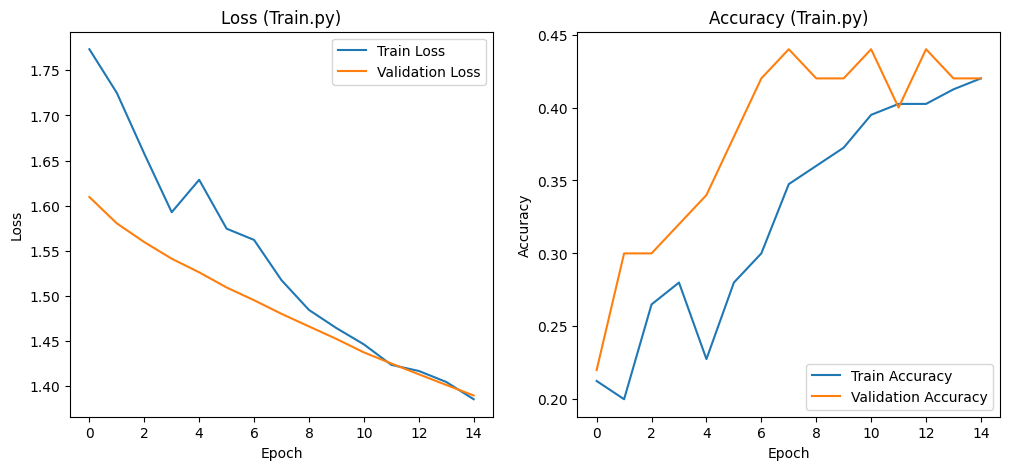

In [9]:
# 5. Visualiser l'entraînement initial
plot_history(train_history, title_suffix='(Train.py)')

Loss :

La loss d’entraînement diminue de manière régulière.

La loss de validation diminue aussi au début mais finit par se stabiliser.

✅ Interprétation : le modèle apprend bien, mais la stabilisation de la loss de validation peut indiquer un début d’overfitting léger.

Accuracy :

L’accuracy d’entraînement augmente progressivement.

L’accuracy de validation fluctue un peu mais suit globalement une tendance à la hausse.

✅ Interprétation : le modèle s’améliore sur le dataset, mais certaines fluctuations montrent qu’il n’est pas encore totalement stable.

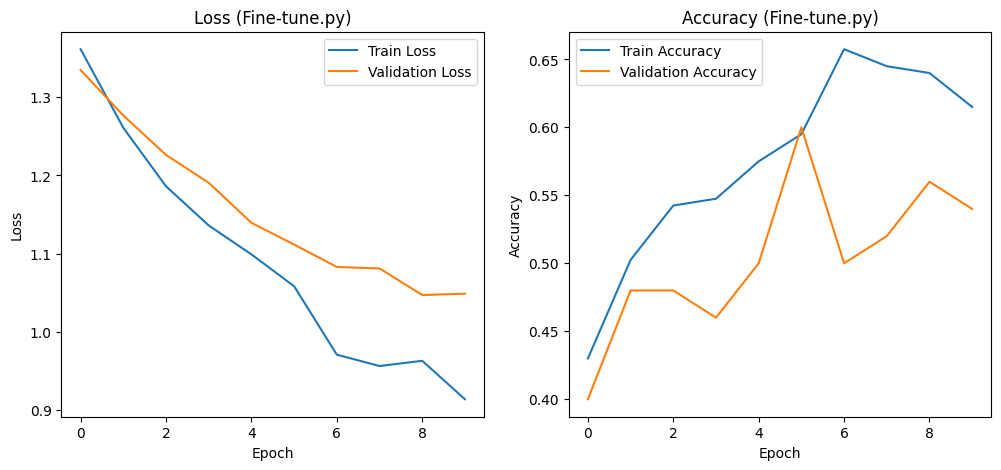

In [10]:
# 6. Visualiser le fine-tuning
plot_history(finetune_history, title_suffix='(Fine-tune.py)')

Loss :

La loss d’entraînement et la loss de validation chutent rapidement au début.

Ensuite, elles se stabilisent à des valeurs plus faibles que lors de l’entraînement initial.

✅ Interprétation : Fine-tuning accélère l’apprentissage sur les couches profondes
                     Fine-tuning améliore la capacité de généralisation

Accuracy :

L’accuracy d’entraînement augmente rapidement mais montre quelques fluctuations.

L’accuracy de validation monte de manière plus régulière et stable.

✅ Interprétation : le fine-tuning améliore la performance globale et la généralisation, rendant le modèle plus robuste sur les données de validation.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [12]:
model_path = '../models/vgg16_finetuned.h5'
model = load_model(model_path)
print("✅ Modèle chargé")


✅ Modèle chargé


In [13]:
#préparation les données de test

test_dir = '../data/Chili_Plant_Disease/test'

test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False  # important pour la correspondance labels/prédictions
)


Found 50 images belonging to 5 classes.


In [14]:
# Prédire les classes
pred_probs = model.predict(test_gen)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())


c:\Users\MSI\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 887ms/step


<Figure size 800x800 with 0 Axes>

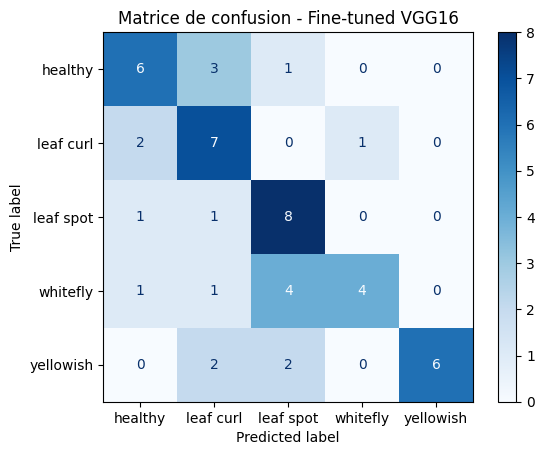

In [15]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(8,8))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Matrice de confusion - Fine-tuned VGG16")
plt.show()


The confusion matrix for the fine-tuned VGG16 model shows strong performance in predicting